# Notebook 11: Explainable AI (XAI) & Adverse Action Generator

## Project: Enterprise Credit Risk Modelling & Independent Model Validation (SR 11-7)

In [1]:
import sys
import os
from pathlib import Path
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

root_path = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
src_path = root_path / "src"
for p in [str(root_path), str(src_path)]:
    if p not in sys.path:
        sys.path.insert(0, p)

sns.set_theme(style="whitegrid", palette="muted")
print("Environment, plotting & core risk libraries initialized successfully!")

Environment, plotting & core risk libraries initialized successfully!


In [2]:
data_file = root_path / "data" / "processed" / "accepted_2007_to_2018Q4_feature_engineered.csv.gz"
if data_file.is_file():
    df = pd.read_csv(data_file, nrows=50000, low_memory=False)
    bad = ["Charged Off", "Default", "Does not meet the credit policy. Status:Charged Off", "Late (31-120 days)"]
    good = ["Fully Paid", "Does not meet the credit policy. Status:Fully Paid"]
    df["target"] = np.nan
    df.loc[df["loan_status"].isin(bad), "target"] = 1.0
    df.loc[df["loan_status"].isin(good), "target"] = 0.0
    df = df.dropna(subset=["target"]).copy()
    df["target"] = df["target"].astype(int)
    num_cols = ["loan_amnt", "int_rate", "installment", "annual_inc", "dti", "fico_range_low", "revol_util"]
    for c in num_cols:
        if c in df.columns:
            df[c] = df[c].fillna(df[c].median())
else:
    df = mock_df.copy()

print(f"Dataset Loaded: {len(df):,} loans | Default Rate: {df['target'].mean():.4%}")

Dataset Loaded: 44,252 loans | Default Rate: 20.9572%


In [3]:
from explainability.shap_analysis import compute_global_shap
from models.boosting_models import fit_lightgbm
num_feats = ["loan_amnt", "int_rate", "installment", "annual_inc", "dti", "fico_range_low"]
lgb_res = fit_lightgbm(df[num_feats], df["target"])
shap_res = compute_global_shap(lgb_res["model"], df[num_feats].iloc[:500])
shap_res["ranking_table"].head(10)

,feature,mean_abs_shap
0,int_rate,0.667125
1,loan_amnt,0.249377
2,installment,0.182224
3,dti,0.149321
4,fico_range_low,0.145223
5,annual_inc,0.075266


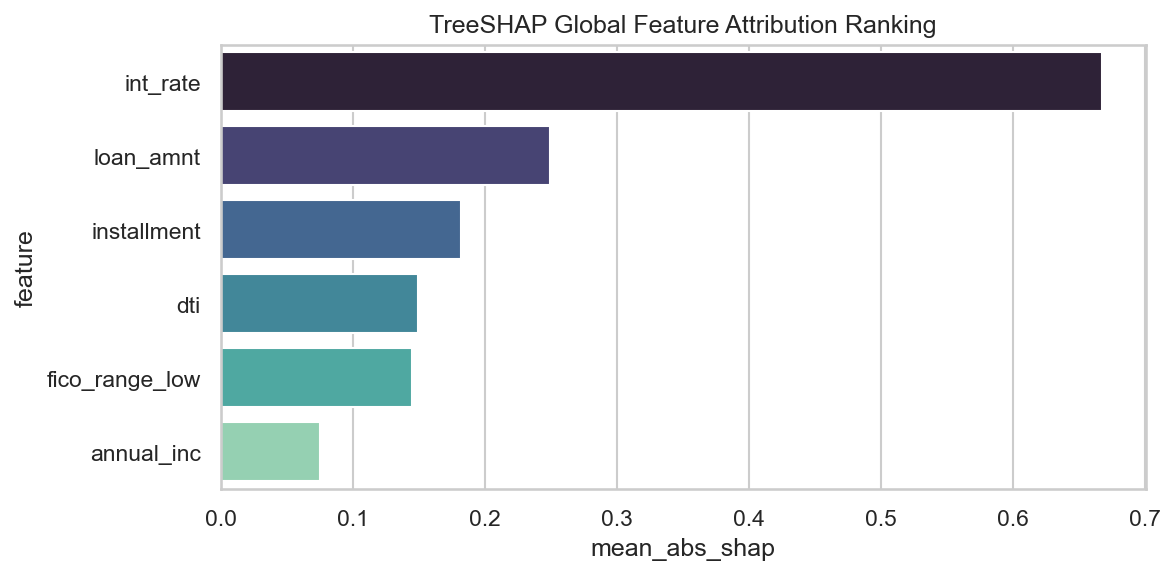

In [4]:
plt.figure(figsize=(8, 4))
top_shap = shap_res["ranking_table"].head(6)
sns.barplot(data=top_shap, x="mean_abs_shap", y="feature", hue="feature", palette="mako", legend=False)
plt.title("TreeSHAP Global Feature Attribution Ranking")
plt.tight_layout()
plt.show()